---
format:
  html:
    code-fold: true
---

# Como tratar os dados experimentais?

Supondo que, após a realização de algumas medições experimentais, o objetivo seja determinar a impedância do sistema. Para isso o seguinte procedimento foi realizado:

1. O sistema foi instrumentado com medidores de tensão e corrente.
2. Utilizando um varivolt, uma tensão alternada foi utilizada para alimentar o sistema.
3. A tensão varia de 0 a 127V.
4. Uma tabela de valores, com 10 pontos foi construída.

### Tabela de medições de tensão e corrente

| ID | Tensão | Corrente | 
| --- | --- | --- |
| 1 | 0.00 | 0.00000 |
| 2 | 14.11 | 0.22 |
| 3 | 28.22 | 0.37 | 
| 4 | 42.33 | 0.55 |
| 5 | 56.44 | 0.84 |
| 6 | 70.55 | 0.96 | 
| 7 | 84.66 | 1.11 |
| 8 | 98.77 | 1.29 |
| 9 | 112.88 | 1.38 |
| 10 | 127.00 | 1.66 |

In [1]:
Vrms = [0 14.11 28.22 42.33 56.44 70.55556 84.66 98.7 112.88 127];
Irms = [0 0.22 0.37 0.55 0.84 0.96 1.11 1.29 1.38 1.66];

### 1$^o$ passo - Calcular a regressão linear

In [2]:
coef = polyfit(Irms, Vrms, 1) % Regressão linear
coef_force_zero = Irms(:)\Vrms(:) % Regressão linear forçando o ponto (0,0)

coef =

   78.4584   -2.2586

coef_force_zero =  76.501


A inclinação do gráfico representa o valor do módulo da impedância.

### 2$^o$ passo - Calcular R$^2$, coeficiente de determinação

In [3]:
rsq1 = corrcoef(Irms, Vrms);
R2 = rsq1(1,2)*rsq1(2,1);

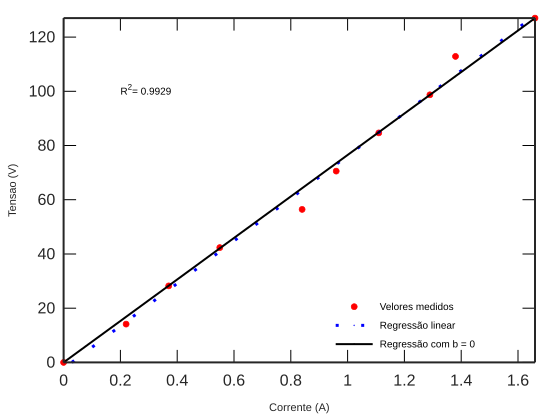

In [12]:
%plot -f svg
warning('off');
plot(Irms, Vrms, '.r','LineWidth', 2, ... 
     Irms, polyval(coef, Irms), ':b', 'LineWidth', 3, ...
     Irms, polyval([coef_force_zero 0], Irms), '-k', 'LineWidth', 2);
legend('Velores medidos', 'Regressão linear', 'Regressão com b = 0 ', 'Location', 'SouthEast'); legend boxoff;
xlabel('Corrente (A)'); ylabel('Tensao (V)'); set(gca, "linewidth", 2, "fontsize", 16)
axis([Irms(1) Irms(end) Vrms(1) Vrms(end)]);
text(.2, 100,  sprintf('R^2 = %.4f', R2));